# Sales Forecasting and Pricing Analysis

For this project I worked with the Sample Superstore dataset. The idea was to forecast future sales and also look at where the business might be losing money through discounting.

I used Prophet for the forecasting part because I read it handles seasonality well without a lot of manual work. Also used Isolation Forest to spot any months that looked unusual.

Dataset: Sample Superstore (retail orders)
Tools: pandas, numpy, matplotlib, Prophet, scikit-learn

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error

Importing plotly failed. Interactive plots will not work.


## Loading the data

The dates were stored as strings so I had to convert them. Also removed any duplicate rows and rows with missing values in the main columns I needed.

In [2]:
mydf = pd.read_csv('Sample_-_Superstore.csv', encoding='latin1')

mydf['Order Date'] = pd.to_datetime(mydf['Order Date'])
mydf['Ship Date'] = pd.to_datetime(mydf['Ship Date'])

mydf = mydf.drop_duplicates()
mydf = mydf.dropna(subset=['Sales', 'Profit', 'Discount', 'Quantity'])

print('Total rows:', len(mydf))
print('Columns:', mydf.shape[1])
mydf.head()

Total rows: 9994
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Adding some new columns

I created a few extra columns that I thought would be useful — profit margin, how much revenue was lost to discounts, and a revenue opportunity score (basically sales minus the discount portion).

In [3]:
mydf['Year'] = mydf['Order Date'].dt.year
mydf['Month'] = mydf['Order Date'].dt.month
mydf['Quarter'] = mydf['Order Date'].dt.quarter

mydf['Profit Margin'] = mydf['Profit'] / mydf['Sales']
mydf['Discount Impact'] = mydf['Sales'] * mydf['Discount'] * -1
mydf['Revenue Opportunity'] = mydf['Sales'] * (1 - mydf['Discount'])

print(mydf[['Sales', 'Profit', 'Discount', 'Profit Margin']].describe().round(2))

          Sales   Profit  Discount  Profit Margin
count   9994.00  9994.00   9994.00        9994.00
mean     229.86    28.66      0.16           0.12
std      623.25   234.26      0.21           0.47
min        0.44 -6599.98      0.00          -2.75
25%       17.28     1.73      0.00           0.08
50%       54.49     8.67      0.20           0.27
75%      209.94    29.36      0.20           0.36
max    22638.48  8399.98      0.80           0.50


## Category level summary

Before doing any forecasting I wanted to see how the three categories compare. I suspected Furniture would have low margins because of the heavy discounting.

In [4]:
cat_summary = mydf.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin', 'mean'),
    Avg_Discount=('Discount', 'mean'),
    Discount_Loss=('Discount Impact', 'sum')
).round(2)

print(cat_summary)

                 Total_Sales  Total_Profit  Avg_Margin  Avg_Discount  \
Category                                                               
Furniture          741999.80      18451.27        0.04          0.17   
Office Supplies    719047.03     122490.80        0.14          0.16   
Technology         836154.03     145454.95        0.16          0.13   

                 Discount_Loss  
Category                        
Furniture           -123516.54  
Office Supplies      -76404.94  
Technology          -122660.65  


Furniture has the highest discount rate and the lowest profit margin by far. Technology does the best on margins. This is useful context for the pricing analysis later.

## Monthly sales for forecasting

Prophet needs data in a specific format — a column called ds for dates and y for values. I grouped the orders by month to get monthly sales totals.

In [5]:
monthly_sales = mydf.resample('ME', on='Order Date')['Sales'].sum().reset_index()
monthly_sales.columns = ['ds', 'y']

print('Number of months:', len(monthly_sales))
print(monthly_sales.tail())

Number of months: 48
           ds            y
43 2017-08-31   63120.8880
44 2017-09-30   87866.6520
45 2017-10-31   77776.9232
46 2017-11-30  118447.8250
47 2017-12-31   83829.3188


## Plotting monthly sales

Just to see what the trend looks like before modelling.

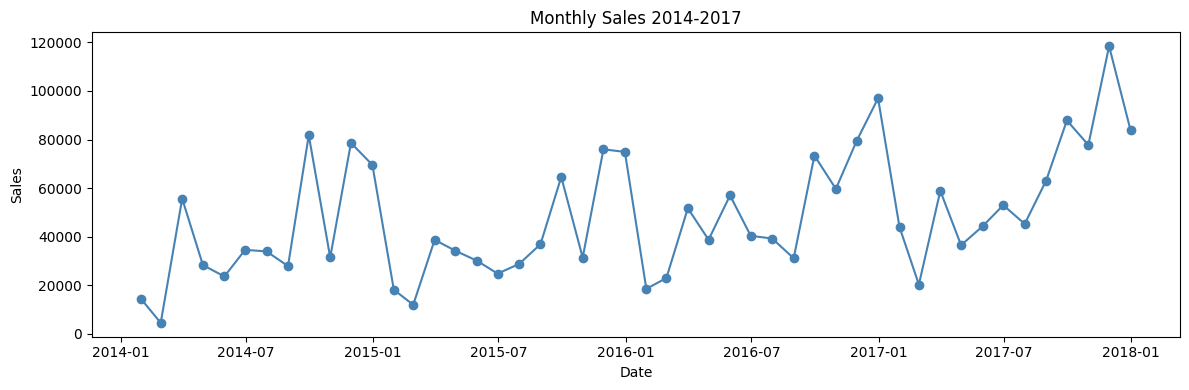

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(monthly_sales['ds'], monthly_sales['y'], marker='o', color='steelblue')
plt.title('Monthly Sales 2014-2017')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('monthly_sales.png')
plt.show()

## Building the forecast with Prophet

I went with yearly seasonality since the data covers 4 years and there's a clear pattern of sales being higher towards the end of the year. Multiplicative mode fits better when the seasonal swings grow as the trend grows.

In [7]:
prophet_model = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
prophet_model.fit(monthly_sales)

future_dates = prophet_model.make_future_dataframe(periods=6, freq='ME')
forecast = prophet_model.predict(future_dates)

print('Next 6 months forecast:')
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))

20:38:35 - cmdstanpy - INFO - Chain [1] start processing


20:38:35 - cmdstanpy - INFO - Chain [1] done processing


Next 6 months forecast:
           ds          yhat    yhat_lower    yhat_upper
48 2018-01-31  36344.188237  26970.158699  46646.746912
49 2018-02-28  21682.946429  11824.982863  30721.124116
50 2018-03-31  73278.079019  63893.911264  82830.571726
51 2018-04-30  50673.903092  41583.160071  59722.215029
52 2018-05-31  49693.999721  39760.161713  59483.706563
53 2018-06-30  51583.299043  42365.603367  60612.186044


## Forecast plot

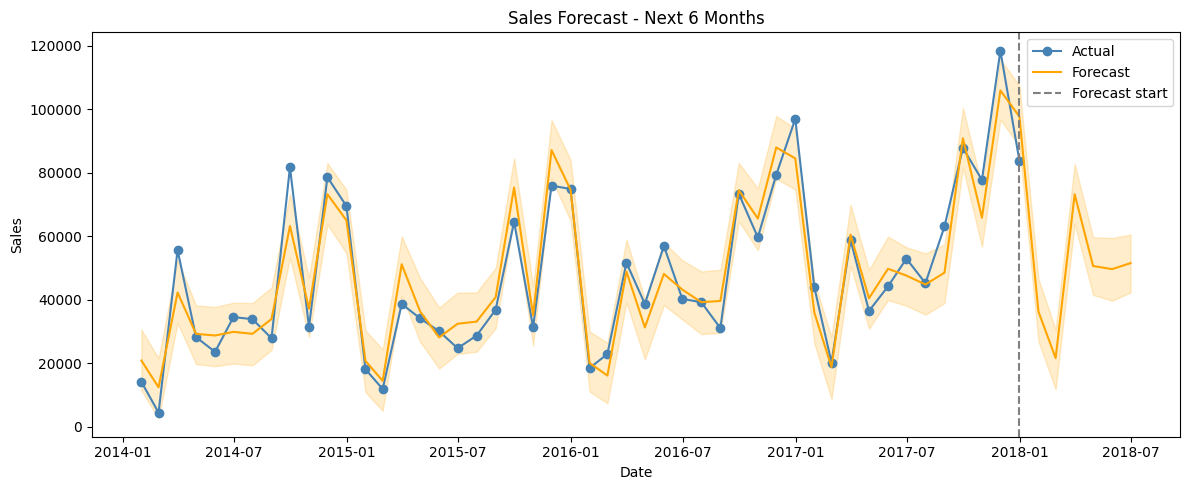

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['ds'], monthly_sales['y'], label='Actual', color='steelblue', marker='o')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='orange')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                 alpha=0.2, color='orange')
plt.axvline(x=monthly_sales['ds'].max(), color='gray', linestyle='--', label='Forecast start')
plt.title('Sales Forecast - Next 6 Months')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('forecast.png')
plt.show()

## Checking forecast accuracy

I merged the actual monthly sales with the predicted values to calculate MAE and RMSE. This is in-sample so it's not a true test set evaluation, but I only have 4 years of monthly data which isn't a lot to split further.

In [9]:
prophet_df = monthly_sales.merge(forecast[['ds', 'yhat']], on='ds', how='left')

mae = mean_absolute_error(prophet_df['y'], prophet_df['yhat'])
rmse = np.sqrt(mean_squared_error(prophet_df['y'], prophet_df['yhat']))

print('MAE:', round(mae, 2))
print('RMSE:', round(rmse, 2))
print('Mean monthly sales:', round(monthly_sales['y'].mean(), 2))

MAE: 6179.83
RMSE: 7551.1
Mean monthly sales: 47858.35


## Anomaly detection

I used Isolation Forest to flag any months where sales looked unusual. Set contamination to 0.1 which means it will flag roughly 10% of months as outliers.

Months flagged as anomalies: 5
           ds           y
0  2014-01-31   14236.895
1  2014-02-28    4519.892
13 2015-02-28   11951.411
35 2016-12-31   96999.043
46 2017-11-30  118447.825


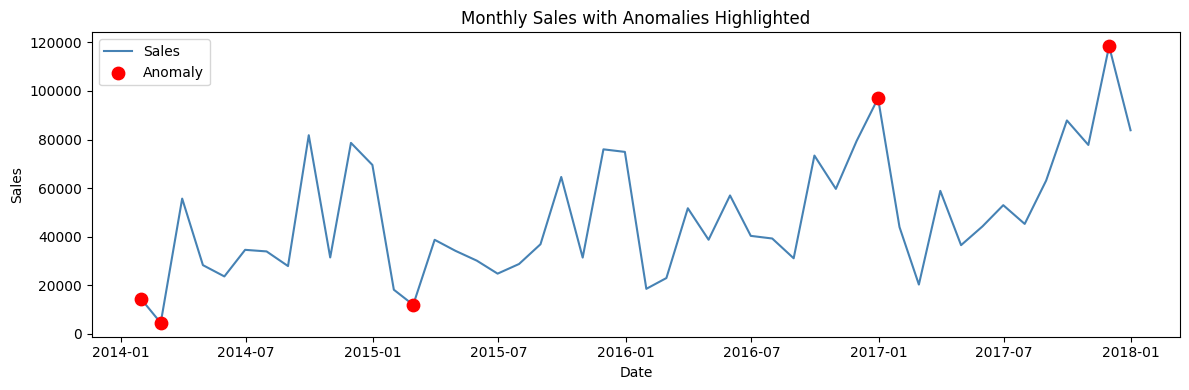

In [10]:
iso_forest = IsolationForest(contamination=0.1, random_state=42)
monthly_sales['anomaly'] = iso_forest.fit_predict(monthly_sales[['y']])

anomalies = monthly_sales[monthly_sales['anomaly'] == -1]
print('Months flagged as anomalies:', len(anomalies))
print(anomalies[['ds', 'y']])

plt.figure(figsize=(12, 4))
plt.plot(monthly_sales['ds'], monthly_sales['y'], color='steelblue', label='Sales')
plt.scatter(anomalies['ds'], anomalies['y'], color='red', s=80, zorder=5, label='Anomaly')
plt.title('Monthly Sales with Anomalies Highlighted')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('anomalies.png')
plt.show()

The big spikes at end of 2016 and 2017 got flagged which makes sense — they stand out visually too. The very low months at the start of 2014 were also flagged, probably because the data starts then and sales were still ramping up.

## Pricing analysis

This part looks at where the discounting is hurting margins and where there's opportunity to recover revenue.

In [11]:
# How many transactions have a profit margin below 10%
low_margin = mydf[mydf['Profit Margin'] < 0.10]
print('Low margin transactions:', len(low_margin), 'out of', len(mydf))

# Revenue lost to discounts by category
print('\nRevenue lost to discounts by category:')
print(mydf.groupby('Category')['Discount Impact'].sum().round(2))

# Top sub-categories by revenue opportunity
rev_opp = mydf.groupby('Sub-Category')['Revenue Opportunity'].sum().sort_values(ascending=False).head(10)
print('\nTop 10 sub-categories by revenue opportunity:')
print(rev_opp.round(2))

Low margin transactions: 3033 out of 9994

Revenue lost to discounts by category:
Category
Furniture         -123516.54
Office Supplies    -76404.94
Technology        -122660.65
Name: Discount Impact, dtype: float64

Top 10 sub-categories by revenue opportunity:
Sub-Category
Phones         281914.11
Chairs         278634.30
Storage        210645.64
Tables         162773.33
Binders        159667.65
Accessories    157578.32
Machines       142472.65
Copiers        131528.30
Appliances     100041.86
Bookcases       94079.41
Name: Revenue Opportunity, dtype: float64


Furniture is losing over 123k to discounts and barely making any profit on it. Phones and Chairs have the highest revenue opportunity scores which means reducing discounts there could have the biggest impact.

## Saving outputs

Exporting the main results as CSVs so they can be used in Tableau or Power BI.

In [12]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('forecast_results.csv', index=False)
monthly_sales[['ds', 'y', 'anomaly']].to_csv('anomaly_results.csv', index=False)
cat_summary.to_csv('category_analysis.csv')
mydf.to_csv('cleaned_data.csv', index=False)

print('All files saved.')

All files saved.
